# Loan Default Prediction Using Machine Learning

## Objective
The objective of this project is to develop machine learning models capable of predicting whether a borrower is likely to default on a loan based on financial and demographic attributes.

Early identification of high-risk borrowers helps financial institutions reduce losses and make data-driven lending decisions.


##⭐ 2️⃣ Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')




In [ ]:

!pip install imbalanced-learn

##⭐ 3️⃣ Load Dataset


In [ ]:
df = pd.read_csv("Loan_default.csv")

df.head()


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0.0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0.0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1.0
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0.0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0.0


##⭐ 4️⃣ Exploratory Data Analysis (EDA)

In [ ]:
df.shape
df.info()
##The dataset contains over 250k records, providing sufficient data for training robust predictive models.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194065 entries, 0 to 194064
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          194065 non-null  object 
 1   Age             194065 non-null  int64  
 2   Income          194065 non-null  int64  
 3   LoanAmount      194065 non-null  int64  
 4   CreditScore     194065 non-null  int64  
 5   MonthsEmployed  194065 non-null  int64  
 6   NumCreditLines  194065 non-null  int64  
 7   InterestRate    194065 non-null  float64
 8   LoanTerm        194065 non-null  int64  
 9   DTIRatio        194065 non-null  float64
 10  Education       194064 non-null  object 
 11  EmploymentType  194064 non-null  object 
 12  MaritalStatus   194064 non-null  object 
 13  HasMortgage     194064 non-null  object 
 14  HasDependents   194064 non-null  object 
 15  LoanPurpose     194064 non-null  object 
 16  HasCoSigner     194064 non-null  object 
 17  Default   

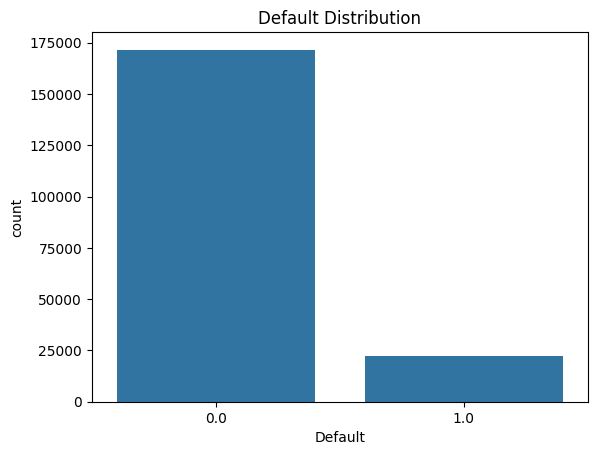

In [ ]:
#Target Distribution
sns.countplot(x='Default', data=df)
plt.title("Default Distribution")
plt.show()


In [ ]:
#missing value
df.isnull().sum()


,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [ ]:
# Monthly Loan Burden
df['Loan_per_Month'] = df['LoanAmount'] / df['LoanTerm']

# Monthly Income
df['Income_per_Month'] = df['Income'] / 12

# Interest Pressure (Total Interest Load Approximation)
df['Interest_Burden'] = df['InterestRate'] * df['LoanAmount']

# Loan weighted by Debt-to-Income
df['DTI_Loan'] = df['DTIRatio'] * df['LoanAmount']

# True Monthly Stress Ratio (VERY POWERFUL)
df['Stress_Ratio'] = df['Loan_per_Month'] / df['Income_per_Month']

# Risk Interaction: Credit weakness * DTI
df['Credit_DTI_Risk'] = (700 - df['CreditScore']) * df['DTIRatio']

df.head()


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,...,HasDependents,LoanPurpose,HasCoSigner,Default,Loan_per_Month,Income_per_Month,Interest_Burden,DTI_Loan,Stress_Ratio,Credit_DTI_Risk
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,...,Yes,Other,Yes,0.0,1405.194444,7166.166667,770440.01,22258.28,0.196087,79.20
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,...,No,Other,Yes,0.0,2074.000000,4202.666667,598556.40,84619.20,0.493496,164.56
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,...,Yes,Auto,No,1.0,5382.833333,7017.333333,2734909.96,40048.28,0.767077,77.19
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,...,No,Business,No,0.0,1866.625000,2642.750000,316728.93,10303.77,0.706319,-9.89
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,...,Yes,Auto,No,0.0,190.395833,1703.083333,59494.89,6671.47,0.111795,48.91


In [ ]:
df.columns


Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default',
       'Loan_per_Month', 'Income_per_Month', 'Interest_Burden', 'DTI_Loan',
       'Stress_Ratio', 'Credit_DTI_Risk'],
      dtype='object')

In [ ]:
df[['Loan_per_Month',
    'Income_per_Month',
    'Interest_Burden',
    'DTI_Loan',
    'Stress_Ratio',
    'Credit_DTI_Risk']].head()


,Loan_per_Month,Income_per_Month,Interest_Burden,DTI_Loan,Stress_Ratio,Credit_DTI_Risk
0,1405.194444,7166.166667,770440.01,22258.28,0.196087,79.20
1,2074.000000,4202.666667,598556.40,84619.20,0.493496,164.56
2,5382.833333,7017.333333,2734909.96,40048.28,0.767077,77.19
3,1866.625000,2642.750000,316728.93,10303.77,0.706319,-9.89
4,190.395833,1703.083333,59494.89,6671.47,0.111795,48.91


In [ ]:
df[['Loan_per_Month',
    'Income_per_Month',
    'Interest_Burden',
    'DTI_Loan',
    'Stress_Ratio',
    'Credit_DTI_Risk']].describe()


,Loan_per_Month,Income_per_Month,Interest_Burden,DTI_Loan,Stress_Ratio,Credit_DTI_Risk
count,194065.000000,194065.000000,1.940650e+05,194065.000000,194065.000000,194065.000000
mean,4840.947570,6875.304924,1.719069e+06,63812.035384,0.994051,62.871902
std,4427.806700,3248.424141,1.358057e+06,48919.423316,1.344535,92.159253
min,83.666667,1250.000000,1.073144e+04,550.990000,0.006791,-134.100000
25%,1841.083333,4064.250000,6.069571e+05,24038.040000,0.266339,-4.290000
50%,3534.055556,6879.166667,1.360494e+06,51299.320000,0.552662,46.200000
75%,6140.833333,9685.750000,2.545263e+06,93892.370000,1.181617,118.800000
max,20832.750000,12499.916667,6.217164e+06,224945.100000,16.367200,360.000000


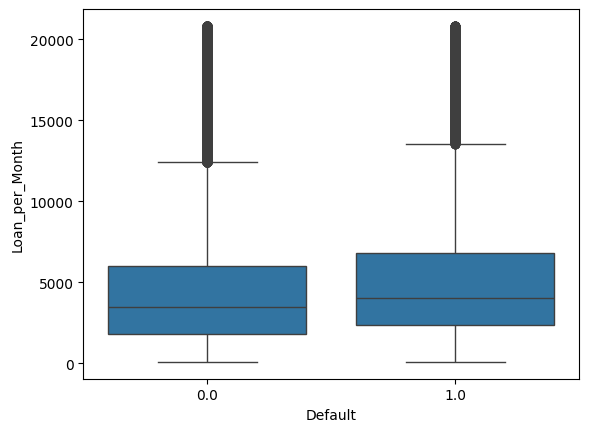

In [ ]:
sns.boxplot(x='Default', y='Loan_per_Month', data=df)
plt.show()


Median is Higher for Defaulters
Look at the middle line inside each box:
Default = 0 → lower median
Default = 1 → clearly higher median
👉 This means:
Defaulters generally have higher financial stress.

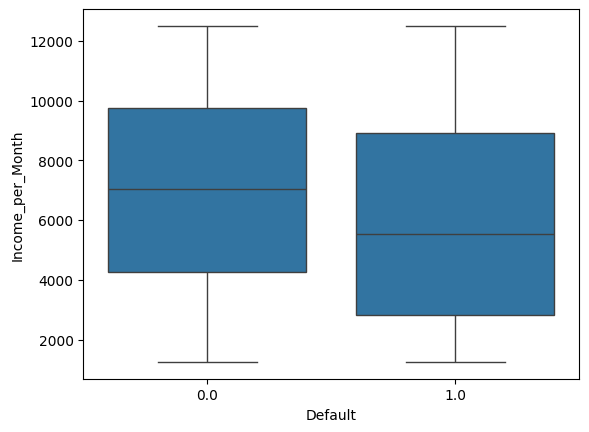

In [ ]:
sns.boxplot(x='Default', y='Income_per_Month', data=df)
plt.show()


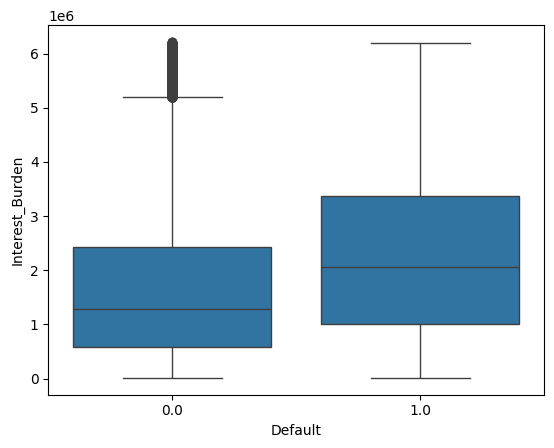

In [ ]:
sns.boxplot(x='Default', y='Interest_Burden', data=df)
plt.show()


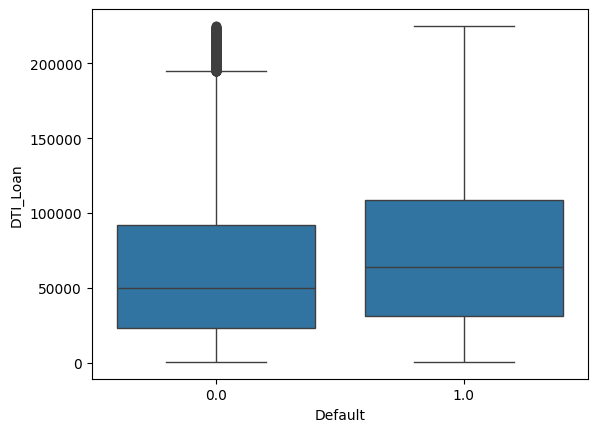

In [ ]:
sns.boxplot(x='Default', y='DTI_Loan', data=df)
plt.show()

In [ ]:

df.groupby('Default')['Stress_Ratio'].mean()


,Stress_Ratio
Default,
0.0,0.928720
1.0,1.492043


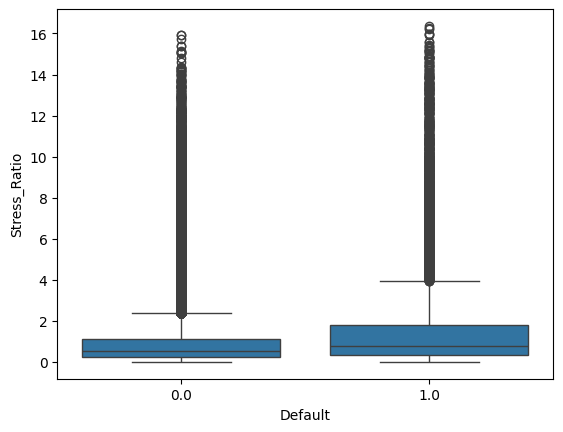

In [ ]:
sns.boxplot(x='Default', y='Stress_Ratio', data=df)
plt.show()


How financially overloaded is this customer?”
And the answer is:
Customers with higher stress are much more likely to default.
The relationship is positive and meaningful.
That’s a strong predictive feature.

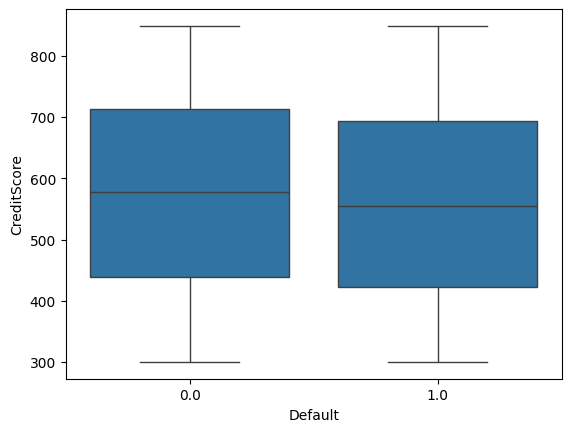

In [ ]:
#Feature vs Default
sns.boxplot(x='Default', y='CreditScore', data=df)
plt.show()
#Borrowers who default tend to have lower credit scores, indicating reduced creditworthiness.


1. Median Credit Score
Non-defaulters median ≈ 580
Defaulters median ≈ 560–570
👉 Difference is very small.

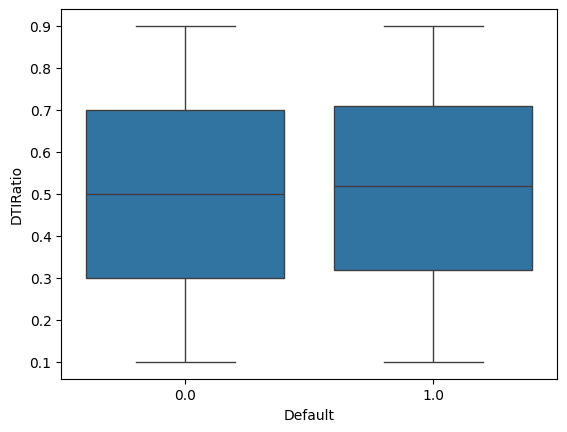

In [ ]:
sns.boxplot(x='Default', y='DTIRatio', data=df)
plt.show()

Non-defaulters (0) → median ≈ 0.50
Defaulters (1) → median ≈ 0.52–0.53
👉 Defaulters have a slightly higher DTI.

Many safe borrowers ALSO have high DTI.
So DTI alone cannot perfectly separate defaulters.


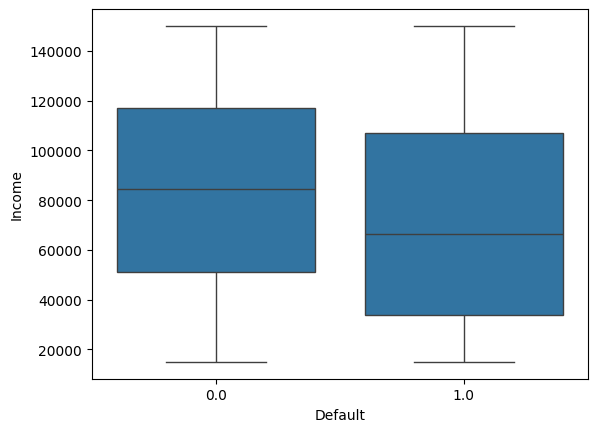

In [ ]:
sns.boxplot(x='Default', y='Income', data=df)
plt.show()

Non-defaulters (0) → median ≈ 85k
Defaulters (1) → median ≈ 65k–70k


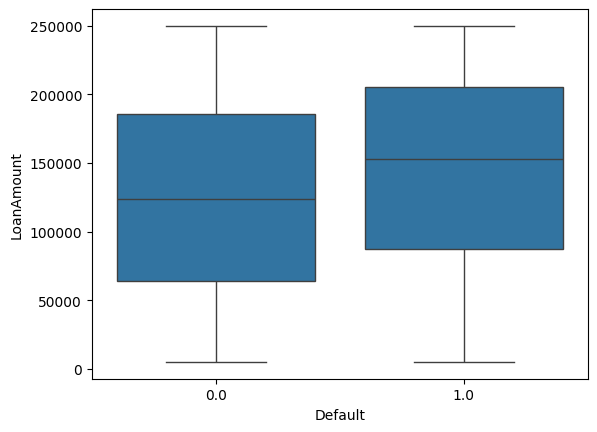

In [ ]:
sns.boxplot(x='Default', y='LoanAmount', data=df)
plt.show()

The boxplot indicates that borrowers who default tend to take larger loan amounts, suggesting that higher repayment obligations significantly contribute to default risk.

In [ ]:
df['Repayment_Stress'] = df['LoanAmount'] - df['Income']
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,...,LoanPurpose,HasCoSigner,Default,Loan_per_Month,Income_per_Month,Interest_Burden,DTI_Loan,Stress_Ratio,Credit_DTI_Risk,Repayment_Stress
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,...,Other,Yes,0.0,1405.194444,7166.166667,770440.01,22258.28,0.196087,79.20,-35407
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,...,Other,Yes,0.0,2074.000000,4202.666667,598556.40,84619.20,0.493496,164.56,74008
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,...,Auto,No,1.0,5382.833333,7017.333333,2734909.96,40048.28,0.767077,77.19,44980
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,...,Business,No,0.0,1866.625000,2642.750000,316728.93,10303.77,0.706319,-9.89,13086
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,...,Auto,No,0.0,190.395833,1703.083333,59494.89,6671.47,0.111795,48.91,-11298


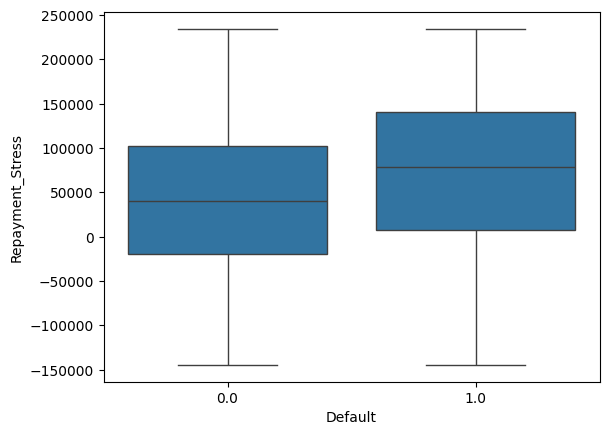

In [ ]:
sns.boxplot(x='Default', y='Repayment_Stress', data=df)
plt.show()


The engineered repayment stress feature shows clear separation between defaulters and non-defaulters, indicating that borrowers with higher financial stretch are significantly more likely to default.


##**DATA PREPROCESSING**

In [ ]:
#Remove Unnecessary Columns
df = df.drop(columns=['LoanID'], errors='ignore')


In [ ]:
#Remove Target NaN
df = df.dropna(subset=['Default'])


In [ ]:
#Separate Target
X = df.drop('Default', axis=1)
y = df['Default']


In [ ]:
print(y.isnull().sum())


0


In [ ]:
X = pd.get_dummies(X, drop_first=True)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [ ]:
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())


0
0


##**Logistic Regression**

In [ ]:
#Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
# It creates synthetic defaulters.

In [ ]:
df = df.dropna(subset=['Default'])
df.reset_index(drop=True, inplace=True)

# NOW recreate
X = df.drop('Default', axis=1)
y = df['Default']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure X is one-hot encoded before scaling
# Assuming 'X' and 'y' are available from previous cells in their non-encoded form after the 'NOW recreate' step
X_encoded = pd.get_dummies(X, drop_first=True)

# Re-split the data after encoding
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
y_pred_lr = lr.predict(X_test_scaled)


##**Run Classification Report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

         0.0       0.94      0.68      0.79     34276
         1.0       0.22      0.70      0.34      4537

    accuracy                           0.68     38813
   macro avg       0.58      0.69      0.57     38813
weighted avg       0.86      0.68      0.74     38813



##**XGBoost Model**

In [ ]:
from xgboost import XGBClassifier

# XGBoost Model
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=3,
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)
y_pred_xgb = xgb.predict(X_test)

print('XGBOOST')
print(classification_report(y_test, y_pred_xgb))

XGBOOST
              precision    recall  f1-score   support

         0.0       0.93      0.89      0.91     34276
         1.0       0.37      0.49      0.42      4537

    accuracy                           0.84     38813
   macro avg       0.65      0.69      0.66     38813
weighted avg       0.86      0.84      0.85     38813



In [ ]:
#GridSearchCV (Hyperparameter Tuning)
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)

param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'scale_pos_weight': [1, 3]
}

grid = GridSearchCV(
    xgb,
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_xgb = grid.best_estimator_


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_xgb, X_encoded, y, cv=5, scoring='roc_auc')

print("CV Scores:", cv_scores)
print("Mean CV ROC-AUC:", cv_scores.mean())

CV Scores: [0.75138244 0.75538321 0.75408477 0.75227078 0.75642875]
Mean CV ROC-AUC: 0.7539099880264293


In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = best_xgb.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

cost_fn = 10000
cost_fp = 2000

total_cost = (fn * cost_fn) + (fp * cost_fp)

print("Total Business Cost:", total_cost)


Total Business Cost: 42492000


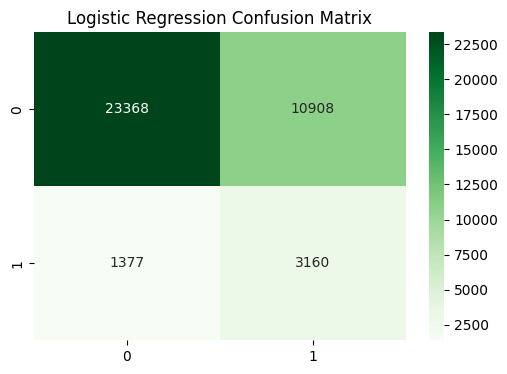

              precision    recall  f1-score   support

         0.0       0.94      0.68      0.79     34276
         1.0       0.22      0.70      0.34      4537

    accuracy                           0.68     38813
   macro avg       0.58      0.69      0.57     38813
weighted avg       0.86      0.68      0.74     38813

Logistic Regression ROC-AUC: 0.758916443378008


In [ ]:
lr_cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Greens')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred_lr))
lr_auc = roc_auc_score(y_test, lr_probs)
print('Logistic Regression ROC-AUC:', lr_auc)

In [ ]:
# ROC AUC
y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]
print('XGBoost AUC:', roc_auc_score(y_test, y_prob_xgb))

XGBoost AUC: 0.7600633423353573


##**Compare Logistic vs XGBoost**

In [ ]:
from sklearn.metrics import recall_score, accuracy_score

print("Logistic Regression")
print("Recall (Class 1):", recall_score(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nXGBoost")
print("Recall (Class 1):", recall_score(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

Logistic Regression
Recall (Class 1): 0.6964954815957681
Accuracy: 0.683482338391776

XGBoost
Recall (Class 1): 0.4864447873043862
Accuracy: 0.8427588694509571


In [ ]:
from sklearn.metrics import roc_auc_score

y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]

print("XGBoost AUC:", roc_auc_score(y_test, y_prob_xgb))

XGBoost AUC: 0.7600633423353573


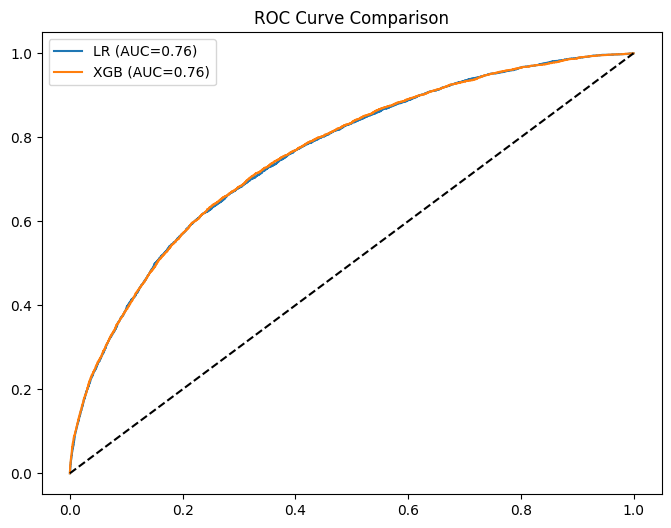

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate probabilities for Logistic Regression
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
# Calculate AUC for Logistic Regression
lr_auc = roc_auc_score(y_test, lr_probs)

# Get XGBoost probabilities (already calculated as y_prob_xgb)
# Get XGBoost AUC (already calculated in a previous cell using y_prob_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))
plt.plot(lr_fpr, lr_tpr, label=f'LR (AUC={lr_auc:.2f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGB (AUC={xgb_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title('ROC Curve Comparison')
plt.show()

In [ ]:
importances = pd.Series(best_xgb.feature_importances_, index=X_encoded.columns)
importances.sort_values(ascending=False).head(10)

,0
Age,0.161949
Interest_Burden,0.113139
Income,0.075453
InterestRate,0.063846
Repayment_Stress,0.054476
MonthsEmployed,0.052787
HasCoSigner_Yes,0.047882
HasDependents_Yes,0.046604
EmploymentType_Unemployed,0.035895
EmploymentType_Self-employed,0.035208


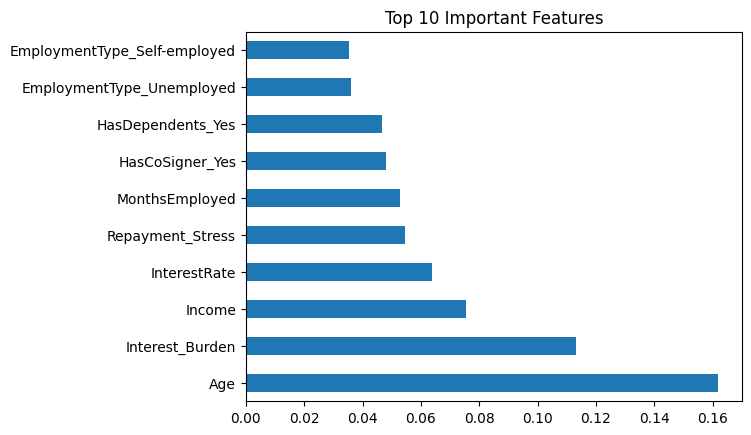

In [ ]:
importances.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

In [ ]:
import joblib
joblib.dump(best_xgb, "loan_default_model.pkl")



['loan_default_model.pkl']